In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, PSARIndicator
from ta.volatility import BollingerBands
from ta.utils import dropna

In [44]:
df = pd.read_csv('EURUSD_Official_OHLCV.csv')
print(df.shape)
df.head()

(5730, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,0
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,0
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,1.212298,0
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,1.208094,0
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,1.218695,0


In [45]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5730 entries, 0 to 5729
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5730 non-null   object 
 1   Open       5730 non-null   float64
 2   High       5730 non-null   float64
 3   Low        5730 non-null   float64
 4   Close      5730 non-null   float64
 5   Adj Close  5730 non-null   float64
 6   Volume     5730 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 313.5+ KB


In [47]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,5730.000000,5730.000000,5730.000000,5730.000000,5730.000000,5730.0
mean,1.224880,1.229370,1.220021,1.224902,1.224902,0.0
std,0.127304,0.128081,0.127454,0.127301,0.127301,0.0
min,0.959619,0.967006,0.072902,0.959619,0.959619,0.0
25%,1.117490,1.121001,1.113467,1.117368,1.117368,0.0
50%,1.206891,1.211438,1.202805,1.207205,1.207205,0.0
75%,1.319801,1.325503,1.314876,1.319962,1.319962,0.0
max,1.598184,1.602821,1.587402,1.598798,1.598798,0.0


In [48]:
df.index.is_monotonic_increasing

True

In [49]:
df['Date'].min()

'2003-12-01'

In [50]:
df['Date'].max()

'2025-12-31'

In [51]:
df.index.duplicated().sum()

0

In [52]:
df['Volume'].describe()

count    5730.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Volume, dtype: float64

In [53]:
(df['Volume']==0).mean()

1.0

In [54]:
(df['Close']==df['Adj Close']).all()

True

In [55]:
full_range = pd.date_range(df.index.min(), df.index.max(), freq='B')
missing_dates = full_range.difference(df.index)
len(missing_dates)

1

<AxesSubplot:title={'center':'EUR/USD Close Over Time'}>

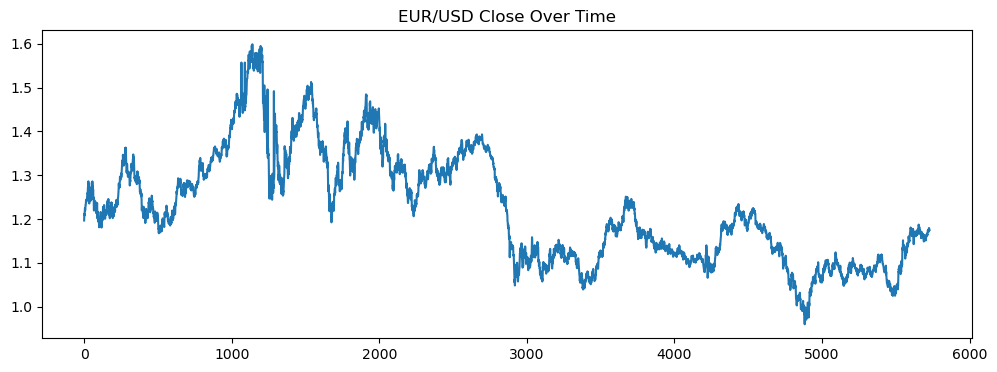

In [56]:
df['Close'].plot(figsize=(12,4), title = "EUR/USD Close Over Time")

In [57]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,0
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,0
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,1.212298,0
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,1.208094,0
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,1.218695,0


# Feature Engeneering

In [58]:
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, PSARIndicator
from ta.volatility import BollingerBands
from ta.utils import dropna

In [59]:
# Compute RSI
df['momentum_rsi'] = RSIIndicator(close=df['Close']).rsi()

In [60]:
df.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,0,NaN
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,0,NaN


In [61]:
# Compute MACD
macd = MACD(close=df['Close'])
df['trend_macd']=macd.macd()
df['trend_macd_signal']=macd.macd_signal()
df['trend_macd_diff']=macd.macd_diff()

In [62]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129


In [63]:
# Compute Bollinger Bands
bollinger = BollingerBands(close=df['Close'])
df['volatility_bbm'] = bollinger.bollinger_mavg()
df['volatility_bbl'] = bollinger.bollinger_lband()
df['volatility_bbh'] = bollinger.bollinger_hband()

In [64]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897,1.168393,1.155841,1.180946
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848,1.169309,1.156605,1.182014
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658,1.170174,1.157776,1.182572
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471,1.171031,1.159165,1.182896
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129,1.171729,1.160752,1.182706


In [65]:
# Compute Parabolic SAR
psar = PSARIndicator(high=df['High'],low=df['Low'], close=df['Close'])
df['trend_psar'] = psar.psar()

In [66]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897,1.168393,1.155841,1.180946,1.171084
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848,1.169309,1.156605,1.182014,1.172460
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658,1.170174,1.157776,1.182572,1.173644
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471,1.171031,1.159165,1.182896,1.180916
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129,1.171729,1.160752,1.182706,1.180790


In [67]:
# Compute Stochastic Oscillator
stochastic = StochasticOscillator(high=df['High'],low=df['Low'],close=df['Close'])
df['momentum_stoch']=stochastic.stoch()
df['momentum_stoch_signal']=stochastic.stoch_signal()

In [68]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897,1.168393,1.155841,1.180946,1.171084,92.898212,73.598855
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848,1.169309,1.156605,1.182014,1.172460,87.617459,86.624612
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658,1.170174,1.157776,1.182572,1.173644,81.048460,87.188043
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471,1.171031,1.159165,1.182896,1.180916,80.575126,83.080348
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129,1.171729,1.160752,1.182706,1.180790,50.935423,70.853003


In [69]:
# Create Lag Features
df['Close_Lag1']=df['Close'].shift()

In [70]:
print(df.shape)
df.tail()

(5730, 18)


,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897,1.168393,1.155841,1.180946,1.171084,92.898212,73.598855,1.176595
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848,1.169309,1.156605,1.182014,1.172460,87.617459,86.624612,1.179551
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658,1.170174,1.157776,1.182572,1.173644,81.048460,87.188043,1.178536
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471,1.171031,1.159165,1.182896,1.180916,80.575126,83.080348,1.177274
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129,1.171729,1.160752,1.182706,1.180790,50.935423,70.853003,1.177288


In [71]:
df['bb_percent_b'] = (df['Close']-df['volatility_bbl'])/(df['volatility_bbh']-df['volatility_bbl'])

In [72]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897,1.168393,1.155841,1.180946,1.171084,92.898212,73.598855,1.176595,0.944467
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848,1.169309,1.156605,1.182014,1.172460,87.617459,86.624612,1.179551,0.863147
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658,1.170174,1.157776,1.182572,1.173644,81.048460,87.188043,1.178536,0.786342
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471,1.171031,1.159165,1.182896,1.180916,80.575126,83.080348,1.177274,0.763668
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129,1.171729,1.160752,1.182706,1.180790,50.935423,70.853003,1.177288,0.636660


In [73]:
df['bb_width']=(df['volatility_bbh']-df['volatility_bbm'])/df['volatility_bbm']

In [74]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,0.000897,1.168393,1.155841,1.180946,1.171084,92.898212,73.598855,1.176595,0.944467,0.010743
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,0.000848,1.169309,1.156605,1.182014,1.172460,87.617459,86.624612,1.179551,0.863147,0.010865
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,0.000658,1.170174,1.157776,1.182572,1.173644,81.048460,87.188043,1.178536,0.786342,0.010595
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,0.000471,1.171031,1.159165,1.182896,1.180916,80.575126,83.080348,1.177274,0.763668,0.010132
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,0.000129,1.171729,1.160752,1.182706,1.180790,50.935423,70.853003,1.177288,0.636660,0.009369


In [75]:
df['above_psar']=(df['Close']>df['trend_psar']).astype(int)

In [76]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,...,volatility_bbm,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,...,1.168393,1.155841,1.180946,1.171084,92.898212,73.598855,1.176595,0.944467,0.010743,1
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,...,1.169309,1.156605,1.182014,1.172460,87.617459,86.624612,1.179551,0.863147,0.010865,1
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,...,1.170174,1.157776,1.182572,1.173644,81.048460,87.188043,1.178536,0.786342,0.010595,1
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,...,1.171031,1.159165,1.182896,1.180916,80.575126,83.080348,1.177274,0.763668,0.010132,0
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,...,1.171729,1.160752,1.182706,1.180790,50.935423,70.853003,1.177288,0.636660,0.009369,0


In [77]:
df['Target']=df['Close'].shift(-1)

In [78]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,momentum_rsi,trend_macd,trend_macd_signal,...,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
5725,2025-12-24,1.179565,1.180916,1.177426,1.179551,1.179551,0,69.581354,0.004386,0.003488,...,1.155841,1.180946,1.171084,92.898212,73.598855,1.176595,0.944467,0.010743,1,1.178536
5726,2025-12-26,1.178384,1.179941,1.176304,1.178536,1.178536,0,67.296544,0.004548,0.003700,...,1.156605,1.182014,1.172460,87.617459,86.624612,1.179551,0.863147,0.010865,1,1.177274
5727,2025-12-29,1.177496,1.178856,1.175406,1.177274,1.177274,0,64.460963,0.004523,0.003865,...,1.157776,1.182572,1.173644,81.048460,87.188043,1.178536,0.786342,0.010595,1,1.177288
5728,2025-12-30,1.177302,1.178134,1.174619,1.177288,1.177288,0,64.478770,0.004453,0.003983,...,1.159165,1.182896,1.180916,80.575126,83.080348,1.177274,0.763668,0.010132,0,1.174729
5729,2025-12-31,1.174646,1.175876,1.172086,1.174729,1.174729,0,58.671383,0.004144,0.004015,...,1.160752,1.182706,1.180790,50.935423,70.853003,1.177288,0.636660,0.009369,0,NaN


In [79]:
 df1 = df.drop(columns=['Volume'], axis = 1)

In [80]:
df1.head()

,Date,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,...,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,NaN,NaN,NaN,NaN,...,NaN,NaN,1.196501,NaN,NaN,NaN,NaN,NaN,0,1.208897
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,NaN,NaN,NaN,NaN,...,NaN,NaN,1.208897,NaN,NaN,1.196501,NaN,NaN,0,1.212298
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,1.212298,NaN,NaN,NaN,NaN,...,NaN,NaN,1.204007,NaN,NaN,1.208897,NaN,NaN,1,1.208094
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,1.208094,NaN,NaN,NaN,NaN,...,NaN,NaN,1.207700,NaN,NaN,1.212298,NaN,NaN,1,1.218695
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,1.218695,NaN,NaN,NaN,NaN,...,NaN,NaN,1.214403,NaN,NaN,1.208094,NaN,NaN,1,1.222001


In [81]:
df1.to_csv('EURUSD_Official_Fetures_Included.csv',index=False)

In [82]:
df = pd.read_csv('EURUSD_Official_Fetures_Included.csv')
print(df1.shape)
df1.head()

(5730, 21)


,Date,Open,High,Low,Close,Adj Close,momentum_rsi,trend_macd,trend_macd_signal,trend_macd_diff,...,volatility_bbl,volatility_bbh,trend_psar,momentum_stoch,momentum_stoch_signal,Close_Lag1,bb_percent_b,bb_width,above_psar,Target
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,1.196501,NaN,NaN,NaN,NaN,...,NaN,NaN,1.196501,NaN,NaN,NaN,NaN,NaN,0,1.208897
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,1.208897,NaN,NaN,NaN,NaN,...,NaN,NaN,1.208897,NaN,NaN,1.196501,NaN,NaN,0,1.212298
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,1.212298,NaN,NaN,NaN,NaN,...,NaN,NaN,1.204007,NaN,NaN,1.208897,NaN,NaN,1,1.208094
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,1.208094,NaN,NaN,NaN,NaN,...,NaN,NaN,1.207700,NaN,NaN,1.212298,NaN,NaN,1,1.218695
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,1.218695,NaN,NaN,NaN,NaN,...,NaN,NaN,1.214403,NaN,NaN,1.208094,NaN,NaN,1,1.222001
